# Notebook 24 — LAM Fingerprint Audit

## Goal

This notebook audits whether controlled loss of active material (LAM) produces diagnostic fingerprints that are separable from both SEI-only aging and pure contact/ohmic resistance growth.

The purpose is to test whether LAM generates stronger voltage-shape and derivative-feature signatures than SEI-only aging.

## Scientific context

Previous mechanism branches established two reference fingerprints:

- SEI-only aging: capacity-dominant, voltage-secondary, derivative-auxiliary.
- Contact / ohmic resistance growth: Ri(t)-dominant, post-ohmic-relaxation-invariant, capacity-weak.

LAM is expected to behave differently because active-material loss can alter:

- usable capacity,
- electrode stoichiometric window,
- V(Q) curve shape,
- ICA/DVA peak position and shape,
- endpoint / voltage-boundary behavior.

## Mechanism branch

This notebook uses a controlled LAM-state perturbation rather than a dynamic aging pathway.

LAM is imposed by scaling active material volume fraction:

- baseline: no active material loss,
- NE-LAM: negative electrode active material volume fraction reduced,
- PE-LAM: positive electrode active material volume fraction reduced.

Initial LAM levels:

- 5%,
- 10%,
- 20%.

## Mechanism Fingerprint Registry v0.2

This notebook reuses the registry established in Notebook 23:

- `capacity_RPT`
- `Ri_0.05s`
- `Ri_0.1s`
- `Ri_1s`
- `Ri_10s`
- `Ri_recovery_0.1s`
- `Ri_recovery_1s`
- `tau_FG_eff`
- `t95`
- `t99`
- `tau_tail`
- `recovery_amplitude`
- `recovery_area`
- `C25_central_VQ`
- `GITT_finite_rest`
- `ICA_DVA_central`
- `endpoint_boundary`
- `best_fitting_targets`
- `rejection_flags`

## Phase A scope

This first LAM audit focuses on:

1. capacity RPT,
2. C/25 OCV-like V(Q),
3. central-window voltage drift,
4. ICA/DVA central derivative features,
5. endpoint / boundary behavior,
6. best fitting target classification.

HPPC Ri(t), corrected relaxation descriptors, and GITT-like finite-rest reconstruction are deferred unless Phase A shows that LAM produces a promising voltage-shape fingerprint.

## Interpretation boundary

A controlled reduction of active material volume fraction is not equivalent to a full experimentally aged LAM trajectory.

This branch is used to test observability and feature separability. Mechanism realism requires later validation using either dynamic LAM model options or experimental measurements.

A feature is not accepted as a primary fitting target unless it passes the established rejection rules:

- signal larger than smoothing sensitivity,
- monotonic trend across LAM severity,
- not endpoint-only,
- not strongly preprocessing-dependent,
- physically linked to the imposed mechanism,
- not obviously non-unique,
- signal larger than protocol sensitivity.

In [1]:
# Cell 1 — Imports, paths, and environment check（导入依赖、路径与环境检查）

from pathlib import Path
import warnings
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pybamm

warnings.filterwarnings("ignore", category=UserWarning)

REPO = Path("/Users/louislu/projects/pybamm-aging-bridge")
DATA = REPO / "data"
FIGURES = REPO / "figures"
DOC_FIGURES = REPO / "docs" / "figures"
DOC_TABLES = REPO / "docs" / "tables"

for p in [DATA, FIGURES, DOC_FIGURES, DOC_TABLES]:
    p.mkdir(parents=True, exist_ok=True)

print("[ENV] PyBaMM:", pybamm.__version__)
print("[ENV] Repository:", REPO)
print("[ENV] Data dir:", DATA)
print("[ENV] Figures dir:", FIGURES)

assert pybamm.__version__ == "26.3.1", "Expected PyBaMM 26.3.1 for this project."
assert REPO.exists(), f"Repository path does not exist: {REPO}"

print("[OK] Environment check passed.")

[ENV] PyBaMM: 26.3.1
[ENV] Repository: /Users/louislu/projects/pybamm-aging-bridge
[ENV] Data dir: /Users/louislu/projects/pybamm-aging-bridge/data
[ENV] Figures dir: /Users/louislu/projects/pybamm-aging-bridge/figures
[OK] Environment check passed.


In [2]:
# Cell 2 — Mechanism Fingerprint Registry v0.2 loading and LAM contract
# （机制指纹注册表 v0.2 读取与 LAM 分支合同）

registry_path = DATA / "mechanism_fingerprint_registry_v0_2.csv"

if registry_path.exists():
    fingerprint_registry_v02 = pd.read_csv(registry_path)
    print(f"[OK] loaded registry: {registry_path}")
else:
    raise FileNotFoundError(
        "Mechanism Fingerprint Registry v0.2 not found. "
        "Run Notebook 23 first or restore mechanism_fingerprint_registry_v0_2.csv."
    )

display(fingerprint_registry_v02)

LAM_CONTRACT = pd.DataFrame([
    {
        "branch": "baseline",
        "electrode": "none",
        "LAM_fraction": 0.0,
        "interpretation": "reference state without controlled active-material loss",
    },
    {
        "branch": "NE_LAM",
        "electrode": "negative",
        "LAM_fraction": 0.05,
        "interpretation": "5% negative-electrode active material volume fraction reduction",
    },
    {
        "branch": "NE_LAM",
        "electrode": "negative",
        "LAM_fraction": 0.10,
        "interpretation": "10% negative-electrode active material volume fraction reduction",
    },
    {
        "branch": "NE_LAM",
        "electrode": "negative",
        "LAM_fraction": 0.20,
        "interpretation": "20% negative-electrode active material volume fraction reduction",
    },
    {
        "branch": "PE_LAM",
        "electrode": "positive",
        "LAM_fraction": 0.05,
        "interpretation": "5% positive-electrode active material volume fraction reduction",
    },
    {
        "branch": "PE_LAM",
        "electrode": "positive",
        "LAM_fraction": 0.10,
        "interpretation": "10% positive-electrode active material volume fraction reduction",
    },
    {
        "branch": "PE_LAM",
        "electrode": "positive",
        "LAM_fraction": 0.20,
        "interpretation": "20% positive-electrode active material volume fraction reduction",
    },
])

LAM_CONTRACT["condition"] = LAM_CONTRACT.apply(
    lambda r: "baseline" if r["branch"] == "baseline"
    else f'{r["branch"]}_{int(r["LAM_fraction"]*100)}pct',
    axis=1
)

contract_path = DATA / "lam_fingerprint_branch_contract.csv"
LAM_CONTRACT.to_csv(contract_path, index=False)

print(f"[OK] saved: {contract_path}")
display(LAM_CONTRACT)

[OK] loaded registry: /Users/louislu/projects/pybamm-aging-bridge/data/mechanism_fingerprint_registry_v0_2.csv


,metric_layer,description,primary_use,risk
0,capacity_RPT,External discharge capacity / capacity fade fr...,primary fitting target for capacity-loss mecha...,voltage cutoff can mix true capacity loss with...
1,Ri_0.05s,Pulse-on resistance at 50 ms,ohmic / very-fast polarization target,trigger and sampling-window sensitive
2,Ri_0.1s,Pulse-on resistance at 100 ms,ohmic / fast polarization target,still partly sensitive to pulse detection and ...
3,Ri_1s,Pulse-on resistance at 1 s,fast-to-medium polarization response,already includes non-ohmic transient contribution
4,Ri_10s,Pulse-on resistance near pulse end at 10 s,slow polarization / diffusion-sensitive resist...,strongly time-window dependent
5,Ri_recovery_0.1s,Pulse-off recovery resistance at 100 ms after ...,current-off ohmic / fast recovery descriptor,sensitive to pulse-off timing
6,Ri_recovery_1s,Pulse-off recovery resistance at 1 s after cur...,short recovery descriptor,mixes ohmic and early relaxation response
7,tau_FG_eff,Effective 63.2% voltage-recovery time after pu...,secondary relaxation descriptor,depends on U_inf and relaxation window
8,t95,Time to reach 95% of finite-window recovery am...,relaxation completion descriptor,sensitive to final-voltage definition
9,t99,Time to reach 99% of finite-window recovery am...,slow-tail recovery descriptor,sensitive to numerical floor and U_inf drift


[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/lam_fingerprint_branch_contract.csv


,branch,electrode,LAM_fraction,interpretation,condition
0,baseline,none,0.00,reference state without controlled active-mate...,baseline
1,NE_LAM,negative,0.05,5% negative-electrode active material volume f...,NE_LAM_5pct
2,NE_LAM,negative,0.10,10% negative-electrode active material volume ...,NE_LAM_10pct
3,NE_LAM,negative,0.20,20% negative-electrode active material volume ...,NE_LAM_20pct
4,PE_LAM,positive,0.05,5% positive-electrode active material volume f...,PE_LAM_5pct
5,PE_LAM,positive,0.10,10% positive-electrode active material volume ...,PE_LAM_10pct
6,PE_LAM,positive,0.20,20% positive-electrode active material volume ...,PE_LAM_20pct


## Methodological boundary before LAM execution

Notebook 24 uses controlled active-material volume-fraction scaling.

This is a mechanism-contrast audit, not a complete LAM aging simulation.

A useful LAM fingerprint should differ from:

- SEI-only aging: capacity-dominant and voltage-secondary;
- contact resistance growth: Ri(t)-dominant and relaxation-invariant.

LAM is expected to affect capacity and voltage-curve shape more strongly than pure SEI growth, and may produce more meaningful ICA/DVA central-window changes.

In [3]:
# Cell 3 — Controlled LAM model builder and parameter audit（受控 LAM 模型构建与参数审计）

NEG_AM_KEY = "Negative electrode active material volume fraction"
POS_AM_KEY = "Positive electrode active material volume fraction"


def build_lam_state_model(electrode="none", lam_fraction=0.0):
    """
    Build OKane2022 DFN with controlled active material volume-fraction scaling.

    electrode:
        "none"     -> baseline
        "negative" -> reduce negative electrode active material volume fraction
        "positive" -> reduce positive electrode active material volume fraction
    """
    model = pybamm.lithium_ion.DFN({
        "SEI": "none",
        "lithium plating": "none",
        "loss of active material": "none",
        "particle mechanics": "none",
        "thermal": "isothermal",
    })

    pv = pybamm.ParameterValues("OKane2022")

    neg_base = float(pv[NEG_AM_KEY])
    pos_base = float(pv[POS_AM_KEY])

    neg_scaled = neg_base
    pos_scaled = pos_base

    if electrode == "negative":
        neg_scaled = neg_base * (1.0 - lam_fraction)
    elif electrode == "positive":
        pos_scaled = pos_base * (1.0 - lam_fraction)
    elif electrode == "none":
        pass
    else:
        raise ValueError(f"Unknown electrode: {electrode}")

    pv.update({
        NEG_AM_KEY: neg_scaled,
        POS_AM_KEY: pos_scaled,
    })

    meta = {
        "neg_am_base": neg_base,
        "pos_am_base": pos_base,
        "neg_am_scaled": neg_scaled,
        "pos_am_scaled": pos_scaled,
        "neg_am_change_pct": (neg_scaled / neg_base - 1.0) * 100,
        "pos_am_change_pct": (pos_scaled / pos_base - 1.0) * 100,
    }

    return model, pv, meta


def make_solver():
    return pybamm.CasadiSolver(
        mode="safe",
        atol=1e-6,
        rtol=1e-6,
        dt_max=600,
    )


lam_meta_rows = []

for _, r in LAM_CONTRACT.iterrows():
    model, pv, meta = build_lam_state_model(
        electrode=r["electrode"],
        lam_fraction=float(r["LAM_fraction"]),
    )
    meta_row = {
        "condition": r["condition"],
        "branch": r["branch"],
        "electrode": r["electrode"],
        "LAM_fraction": float(r["LAM_fraction"]),
        **meta,
    }
    lam_meta_rows.append(meta_row)
    print(
        f"[OK] built {r['condition']}: "
        f"neg_AM={meta['neg_am_scaled']:.6f}, "
        f"pos_AM={meta['pos_am_scaled']:.6f}"
    )

lam_parameter_audit = pd.DataFrame(lam_meta_rows)

param_audit_path = DATA / "lam_fingerprint_parameter_audit.csv"
lam_parameter_audit.to_csv(param_audit_path, index=False)

print(f"[OK] saved: {param_audit_path}")
display(lam_parameter_audit)

[OK] built baseline: neg_AM=0.750000, pos_AM=0.665000
[OK] built NE_LAM_5pct: neg_AM=0.712500, pos_AM=0.665000
[OK] built NE_LAM_10pct: neg_AM=0.675000, pos_AM=0.665000
[OK] built NE_LAM_20pct: neg_AM=0.600000, pos_AM=0.665000
[OK] built PE_LAM_5pct: neg_AM=0.750000, pos_AM=0.631750
[OK] built PE_LAM_10pct: neg_AM=0.750000, pos_AM=0.598500
[OK] built PE_LAM_20pct: neg_AM=0.750000, pos_AM=0.532000
[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/lam_fingerprint_parameter_audit.csv


,condition,branch,electrode,LAM_fraction,neg_am_base,pos_am_base,neg_am_scaled,pos_am_scaled,neg_am_change_pct,pos_am_change_pct
0,baseline,baseline,none,0.00,0.75,0.665,0.7500,0.66500,0.0,0.0
1,NE_LAM_5pct,NE_LAM,negative,0.05,0.75,0.665,0.7125,0.66500,-5.0,0.0
2,NE_LAM_10pct,NE_LAM,negative,0.10,0.75,0.665,0.6750,0.66500,-10.0,0.0
3,NE_LAM_20pct,NE_LAM,negative,0.20,0.75,0.665,0.6000,0.66500,-20.0,0.0
4,PE_LAM_5pct,PE_LAM,positive,0.05,0.75,0.665,0.7500,0.63175,0.0,-5.0
5,PE_LAM_10pct,PE_LAM,positive,0.10,0.75,0.665,0.7500,0.59850,0.0,-10.0
6,PE_LAM_20pct,PE_LAM,positive,0.20,0.75,0.665,0.7500,0.53200,0.0,-20.0


In [4]:
# Cell 4 — Diagnostic protocol constants for LAM fingerprint（LAM 指纹诊断协议常数）

CAPACITY_RPT_STEPS = [
    "Discharge at C/3 until 2.5 V",
    "Rest for 60 minutes",
]
CAPACITY_RPT_PERIOD = "60 seconds"

C25_OCV_STEPS = [
    "Discharge at C/25 until 2.5 V",
    "Rest for 60 minutes",
]
C25_OCV_PERIOD = "60 seconds"

# Current ranges for OKane2022 nominal 5 Ah class cell
CAPACITY_CURRENT_LO_A = 1.4
CAPACITY_CURRENT_HI_A = 1.9
CAPACITY_DURATION_LO_MIN = 120
CAPACITY_DURATION_HI_MIN = 230

C25_CURRENT_LO_A = 0.15
C25_CURRENT_HI_A = 0.25
C25_DURATION_LO_MIN = 1000
C25_DURATION_HI_MIN = 1700

CENTRAL_Q_LO_AH = 0.20
CENTRAL_Q_HI_AH = 4.50

SMOOTHING_WINDOWS = [21, 41, 81, 121]
REF_SMOOTHING_WINDOW = 41

print("[CONFIG] capacity RPT steps:", CAPACITY_RPT_STEPS)
print("[CONFIG] C/25 OCV-like steps:", C25_OCV_STEPS)
print("[CONFIG] smoothing windows:", SMOOTHING_WINDOWS)
print("[OK] Protocol constants defined.")

[CONFIG] capacity RPT steps: ['Discharge at C/3 until 2.5 V', 'Rest for 60 minutes']
[CONFIG] C/25 OCV-like steps: ['Discharge at C/25 until 2.5 V', 'Rest for 60 minutes']
[CONFIG] smoothing windows: [21, 41, 81, 121]
[OK] Protocol constants defined.


In [5]:
# Cell 5 — Run LAM capacity RPT and C/25 diagnostic branches（运行 LAM 容量 RPT 与 C/25 诊断分支）

def run_lam_experiment(condition, electrode, lam_fraction, steps, period, initial_soc=1.0):
    model, pv, meta = build_lam_state_model(
        electrode=electrode,
        lam_fraction=lam_fraction,
    )
    experiment = pybamm.Experiment(steps, period=period)

    sim = pybamm.Simulation(
        model,
        parameter_values=pv,
        experiment=experiment,
        solver=make_solver(),
    )

    print(f"[RUN] {condition} | electrode={electrode} | LAM={lam_fraction:.2f} | steps={len(steps)}")
    sol = sim.solve(initial_soc=initial_soc)
    print(f"[OK] solved: {condition}")
    return sol


capacity_solutions = {}
c25_solutions = {}

t0 = time.perf_counter()

for _, r in LAM_CONTRACT.iterrows():
    condition = r["condition"]
    capacity_solutions[condition] = run_lam_experiment(
        condition=condition,
        electrode=r["electrode"],
        lam_fraction=float(r["LAM_fraction"]),
        steps=CAPACITY_RPT_STEPS,
        period=CAPACITY_RPT_PERIOD,
        initial_soc=1.0,
    )

for _, r in LAM_CONTRACT.iterrows():
    condition = r["condition"]
    c25_solutions[condition] = run_lam_experiment(
        condition=condition,
        electrode=r["electrode"],
        lam_fraction=float(r["LAM_fraction"]),
        steps=C25_OCV_STEPS,
        period=C25_OCV_PERIOD,
        initial_soc=1.0,
    )

elapsed_min = (time.perf_counter() - t0) / 60

print("[OK] All LAM diagnostic branches solved.")
print(f"[RUNTIME] total = {elapsed_min:.2f} min")

[RUN] baseline | electrode=none | LAM=0.00 | steps=2
[OK] solved: baseline
[RUN] NE_LAM_5pct | electrode=negative | LAM=0.05 | steps=2


At t = 521.14, , mxstep steps taken before reaching tout.


[OK] solved: NE_LAM_5pct
[RUN] NE_LAM_10pct | electrode=negative | LAM=0.10 | steps=2


At t = 493.624, , mxstep steps taken before reaching tout.


[OK] solved: NE_LAM_10pct
[RUN] NE_LAM_20pct | electrode=negative | LAM=0.20 | steps=2


At t = 438.517, , mxstep steps taken before reaching tout.


[OK] solved: NE_LAM_20pct
[RUN] PE_LAM_5pct | electrode=positive | LAM=0.05 | steps=2
[OK] solved: PE_LAM_5pct
[RUN] PE_LAM_10pct | electrode=positive | LAM=0.10 | steps=2
[OK] solved: PE_LAM_10pct
[RUN] PE_LAM_20pct | electrode=positive | LAM=0.20 | steps=2


At t = 359.744, , mxstep steps taken before reaching tout.
At t = 119.744, , mxstep steps taken before reaching tout.
At t = 119.744, , mxstep steps taken before reaching tout.
At t = 59.7445, , mxstep steps taken before reaching tout.
At t = 22.2445, , mxstep steps taken before reaching tout.


[OK] solved: PE_LAM_20pct
[RUN] baseline | electrode=none | LAM=0.00 | steps=2
[OK] solved: baseline
[RUN] NE_LAM_5pct | electrode=negative | LAM=0.05 | steps=2
[OK] solved: NE_LAM_5pct
[RUN] NE_LAM_10pct | electrode=negative | LAM=0.10 | steps=2
[OK] solved: NE_LAM_10pct
[RUN] NE_LAM_20pct | electrode=negative | LAM=0.20 | steps=2
[OK] solved: NE_LAM_20pct
[RUN] PE_LAM_5pct | electrode=positive | LAM=0.05 | steps=2
[OK] solved: PE_LAM_5pct
[RUN] PE_LAM_10pct | electrode=positive | LAM=0.10 | steps=2
[OK] solved: PE_LAM_10pct
[RUN] PE_LAM_20pct | electrode=positive | LAM=0.20 | steps=2
[OK] solved: PE_LAM_20pct
[OK] All LAM diagnostic branches solved.
[RUNTIME] total = 0.92 min


In [6]:
# Cell 6 — Segment audit and capacity RPT extraction（分段审计与容量 RPT 提取）

def summarize_current_segments(sol, condition, eps=1e-5):
    t = np.asarray(sol["Time [s]"].entries, dtype=float)
    v = np.asarray(sol["Terminal voltage [V]"].entries, dtype=float)
    i = np.asarray(sol["Current [A]"].entries, dtype=float)

    state = np.where(i > eps, "discharge", np.where(i < -eps, "charge", "rest"))
    change_idx = np.r_[0, np.flatnonzero(state[1:] != state[:-1]) + 1, len(state)]

    rows = []
    for k in range(len(change_idx) - 1):
        a, b = change_idx[k], change_idx[k + 1]
        if b - a < 2:
            continue
        rows.append({
            "condition": condition,
            "segment_id": k,
            "segment_type": state[a],
            "idx_start": int(a),
            "idx_stop": int(b),
            "t_start_s": float(t[a]),
            "t_end_s": float(t[b - 1]),
            "duration_s": float(t[b - 1] - t[a]),
            "duration_min": float((t[b - 1] - t[a]) / 60),
            "U_start_V": float(v[a]),
            "U_end_V": float(v[b - 1]),
            "I_mean_A": float(np.mean(i[a:b])),
            "I_min_A": float(np.min(i[a:b])),
            "I_max_A": float(np.max(i[a:b])),
            "n_points": int(b - a),
        })
    return pd.DataFrame(rows)


def integrate_selected_capacity_Ah(sol, idx_start, idx_stop):
    t = np.asarray(sol["Time [s]"].entries, dtype=float)[idx_start:idx_stop]
    v = np.asarray(sol["Terminal voltage [V]"].entries, dtype=float)[idx_start:idx_stop]
    i = np.asarray(sol["Current [A]"].entries, dtype=float)[idx_start:idx_stop]

    t_rel_s = t - t[0]
    q_Ah = np.zeros_like(t_rel_s)

    if len(t_rel_s) > 1:
        dt_h = np.diff(t_rel_s) / 3600.0
        i_mid = 0.5 * (i[1:] + i[:-1])
        q_Ah[1:] = np.cumsum(i_mid * dt_h)

    return {
        "Q_dis_Ah": float(q_Ah[-1]),
        "U_start_V": float(v[0]),
        "U_end_V": float(v[-1]),
        "I_mean_A": float(np.mean(i)),
        "duration_min": float(t_rel_s[-1] / 60),
        "n_points": int(len(t_rel_s)),
    }


capacity_segment_rows = []
capacity_selected_rows = []
capacity_rpt_rows = []

for condition, sol in capacity_solutions.items():
    seg = summarize_current_segments(sol, condition)
    capacity_segment_rows.append(seg)

    candidates = seg[
        (seg["segment_type"] == "discharge")
        & (seg["I_mean_A"].between(CAPACITY_CURRENT_LO_A, CAPACITY_CURRENT_HI_A))
        & (seg["duration_min"].between(CAPACITY_DURATION_LO_MIN, CAPACITY_DURATION_HI_MIN))
    ].copy()

    if candidates.empty:
        raise RuntimeError(f"No valid capacity RPT segment found for {condition}")

    selected = candidates.sort_values("t_start_s").iloc[-1].to_dict()
    capacity_selected_rows.append(selected)

    cap = integrate_selected_capacity_Ah(
        sol=sol,
        idx_start=int(selected["idx_start"]),
        idx_stop=int(selected["idx_stop"]),
    )
    cap["condition"] = condition
    cap["selected_segment_id"] = int(selected["segment_id"])
    capacity_rpt_rows.append(cap)

lam_capacity_segment_audit = pd.concat(capacity_segment_rows, ignore_index=True)
lam_capacity_selected_audit = pd.DataFrame(capacity_selected_rows)
lam_capacity_rpt_table = pd.DataFrame(capacity_rpt_rows)

lam_capacity_rpt_table = lam_capacity_rpt_table.merge(
    LAM_CONTRACT[["condition", "branch", "electrode", "LAM_fraction"]],
    on="condition",
    how="left",
)

q0 = float(lam_capacity_rpt_table.loc[lam_capacity_rpt_table["condition"] == "baseline", "Q_dis_Ah"].iloc[0])

lam_capacity_rpt_table["capacity_retention_pct"] = lam_capacity_rpt_table["Q_dis_Ah"] / q0 * 100
lam_capacity_rpt_table["capacity_loss_pct_vs_baseline"] = 100 - lam_capacity_rpt_table["capacity_retention_pct"]
lam_capacity_rpt_table["capacity_loss_Ah_vs_baseline"] = q0 - lam_capacity_rpt_table["Q_dis_Ah"]

for df, path in [
    (lam_capacity_segment_audit, DATA / "lam_fingerprint_capacity_segment_audit.csv"),
    (lam_capacity_selected_audit, DATA / "lam_fingerprint_capacity_selected_segment_audit.csv"),
    (lam_capacity_rpt_table, DATA / "lam_fingerprint_capacity_rpt_table.csv"),
]:
    df.to_csv(path, index=False)
    print(f"[OK] saved: {path}")

display(lam_capacity_rpt_table.sort_values(["branch", "LAM_fraction"]))

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/lam_fingerprint_capacity_segment_audit.csv
[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/lam_fingerprint_capacity_selected_segment_audit.csv
[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/lam_fingerprint_capacity_rpt_table.csv


,Q_dis_Ah,U_start_V,U_end_V,I_mean_A,duration_min,n_points,condition,selected_segment_id,branch,electrode,LAM_fraction,capacity_retention_pct,capacity_loss_pct_vs_baseline,capacity_loss_Ah_vs_baseline
1,4.802017,4.128506,2.50001,1.666667,172.872621,174,NE_LAM_5pct,0,NE_LAM,negative,0.05,95.093817,4.906183,0.247751
2,4.553747,4.126194,2.50001,1.666667,163.934891,165,NE_LAM_10pct,0,NE_LAM,negative,0.10,90.177348,9.822652,0.496021
3,4.055658,4.120981,2.50001,1.666667,146.003704,148,NE_LAM_20pct,0,NE_LAM,negative,0.20,80.313756,19.686244,0.994110
4,5.042089,4.130444,2.50001,1.666667,181.515207,183,PE_LAM_5pct,0,PE_LAM,positive,0.05,99.847932,0.152068,0.007679
5,5.033817,4.130209,2.50001,1.666667,181.217412,183,PE_LAM_10pct,0,PE_LAM,positive,0.10,99.684121,0.315879,0.015951
6,4.914759,4.129637,2.50001,1.666667,176.931341,179,PE_LAM_20pct,0,PE_LAM,positive,0.20,97.326438,2.673562,0.135009
0,5.049768,4.130650,2.50001,1.666667,181.791653,183,baseline,0,baseline,none,0.00,100.000000,0.000000,0.000000


In [7]:
# Cell 7 — C/25 OCV-like V(Q) segment audit and curve extraction
# （C/25 近似 OCV 电压曲线选段审计与曲线提取）

c25_segment_rows = []
c25_selected_rows = []
c25_curve_rows = []

for condition, sol in c25_solutions.items():
    seg = summarize_current_segments(sol, condition)
    c25_segment_rows.append(seg)

    candidates = seg[
        (seg["segment_type"] == "discharge")
        & (seg["I_mean_A"].between(C25_CURRENT_LO_A, C25_CURRENT_HI_A))
        & (seg["duration_min"].between(C25_DURATION_LO_MIN, C25_DURATION_HI_MIN))
    ].copy()

    if candidates.empty:
        raise RuntimeError(f"No valid C/25 diagnostic discharge segment found for {condition}")

    selected = candidates.sort_values("t_start_s").iloc[-1].to_dict()
    c25_selected_rows.append(selected)

    a = int(selected["idx_start"])
    b = int(selected["idx_stop"])

    t = np.asarray(sol["Time [s]"].entries, dtype=float)[a:b]
    u = np.asarray(sol["Terminal voltage [V]"].entries, dtype=float)[a:b]
    i = np.asarray(sol["Current [A]"].entries, dtype=float)[a:b]

    t_rel_s = t - t[0]
    q_Ah = np.zeros_like(t_rel_s)

    if len(t_rel_s) > 1:
        dt_h = np.diff(t_rel_s) / 3600.0
        i_mid = 0.5 * (i[1:] + i[:-1])
        q_Ah[1:] = np.cumsum(i_mid * dt_h)

    curve = pd.DataFrame({
        "condition": condition,
        "t_rel_s": t_rel_s,
        "t_rel_h": t_rel_s / 3600.0,
        "Q_dis_Ah": q_Ah,
        "U_V": u,
        "I_A_pybamm": i,
        "segment_id": int(selected["segment_id"]),
    })

    c25_curve_rows.append(curve)

lam_c25_segment_audit = pd.concat(c25_segment_rows, ignore_index=True)
lam_c25_selected_audit = pd.DataFrame(c25_selected_rows)
lam_c25_curve_table = pd.concat(c25_curve_rows, ignore_index=True)

lam_c25_selected_audit = lam_c25_selected_audit.merge(
    LAM_CONTRACT[["condition", "branch", "electrode", "LAM_fraction"]],
    on="condition",
    how="left",
)

lam_c25_curve_table = lam_c25_curve_table.merge(
    LAM_CONTRACT[["condition", "branch", "electrode", "LAM_fraction"]],
    on="condition",
    how="left",
)

lam_c25_curve_summary = (
    lam_c25_curve_table
    .groupby(["condition", "branch", "electrode", "LAM_fraction"], as_index=False)
    .agg(
        n_points=("Q_dis_Ah", "size"),
        Q_end_Ah=("Q_dis_Ah", "max"),
        U_start_V=("U_V", "first"),
        U_end_V=("U_V", "last"),
        I_mean_A=("I_A_pybamm", "mean"),
        t_end_h=("t_rel_h", "max"),
        selected_segment_id=("segment_id", "first"),
    )
)

for df, path in [
    (lam_c25_segment_audit, DATA / "lam_fingerprint_c25_segment_audit.csv"),
    (lam_c25_selected_audit, DATA / "lam_fingerprint_c25_selected_segment_audit.csv"),
    (lam_c25_curve_table, DATA / "lam_fingerprint_c25_curve_table.csv"),
    (lam_c25_curve_summary, DATA / "lam_fingerprint_c25_curve_summary.csv"),
]:
    df.to_csv(path, index=False)
    print(f"[OK] saved: {path}")

display(lam_c25_selected_audit[[
    "condition", "branch", "LAM_fraction", "segment_id",
    "duration_min", "U_start_V", "U_end_V", "I_mean_A", "n_points"
]].sort_values(["branch", "LAM_fraction"]))

display(lam_c25_curve_summary.sort_values(["branch", "LAM_fraction"]))

print("[OK] C/25 OCV-like V(Q) extraction complete.")

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/lam_fingerprint_c25_segment_audit.csv
[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/lam_fingerprint_c25_selected_segment_audit.csv
[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/lam_fingerprint_c25_curve_table.csv
[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/lam_fingerprint_c25_curve_summary.csv


,condition,branch,LAM_fraction,segment_id,duration_min,U_start_V,U_end_V,I_mean_A,n_points
1,NE_LAM_5pct,NE_LAM,0.05,0,1455.987888,4.189984,2.50001,0.2,1457
2,NE_LAM_10pct,NE_LAM,0.10,0,1381.330107,4.189517,2.50001,0.2,1383
3,NE_LAM_20pct,NE_LAM,0.20,0,1231.509774,4.188400,2.50001,0.2,1233
4,PE_LAM_5pct,PE_LAM,0.05,0,1528.174287,4.190383,2.50001,0.2,1530
5,PE_LAM_10pct,PE_LAM,0.10,0,1525.684251,4.190359,2.50001,0.2,1527
6,PE_LAM_20pct,PE_LAM,0.20,0,1519.859960,4.190297,2.50001,0.2,1521
0,baseline,baseline,0.00,0,1530.481922,4.190404,2.50001,0.2,1532


,condition,branch,electrode,LAM_fraction,n_points,Q_end_Ah,U_start_V,U_end_V,I_mean_A,t_end_h,selected_segment_id
2,NE_LAM_5pct,NE_LAM,negative,0.05,1457,4.853293,4.189984,2.50001,0.2,24.266465,0
0,NE_LAM_10pct,NE_LAM,negative,0.10,1383,4.604434,4.189517,2.50001,0.2,23.022168,0
1,NE_LAM_20pct,NE_LAM,negative,0.20,1233,4.105033,4.188400,2.50001,0.2,20.525163,0
5,PE_LAM_5pct,PE_LAM,positive,0.05,1530,5.093914,4.190383,2.50001,0.2,25.469571,0
3,PE_LAM_10pct,PE_LAM,positive,0.10,1527,5.085614,4.190359,2.50001,0.2,25.428071,0
4,PE_LAM_20pct,PE_LAM,positive,0.20,1521,5.066200,4.190297,2.50001,0.2,25.330999,0
6,baseline,baseline,none,0.00,1532,5.101606,4.190404,2.50001,0.2,25.508032,0


[OK] C/25 OCV-like V(Q) extraction complete.


In [8]:
# Cell 8 — C/25 V(Q) quality audit and common-Q voltage drift
# （C/25 电压曲线质量审计与共同 Q 窗口电压漂移）

quality_rows = []

for condition, g in lam_c25_curve_table.groupby("condition"):
    g = g.sort_values("Q_dis_Ah").reset_index(drop=True)

    dQ = np.diff(g["Q_dis_Ah"].to_numpy(dtype=float))
    dV = np.diff(g["U_V"].to_numpy(dtype=float))

    q_end = float(g["Q_dis_Ah"].iloc[-1])
    u_start = float(g["U_V"].iloc[0])
    u_end = float(g["U_V"].iloc[-1])

    q_nonmono = int(np.sum(dQ <= 0))
    v_increase_count = int(np.sum(dV > 1e-5))
    v_increase_fraction = v_increase_count / max(len(dV), 1)

    pass_quality = (
        len(g) >= 1000
        and q_end > 3.0
        and (u_start - u_end) > 1.0
        and q_nonmono == 0
        and v_increase_fraction < 0.02
    )

    row_meta = g.iloc[0][["branch", "electrode", "LAM_fraction"]].to_dict()

    quality_rows.append({
        "condition": condition,
        **row_meta,
        "n_points": int(len(g)),
        "Q_end_Ah": q_end,
        "U_start_V": u_start,
        "U_end_V": u_end,
        "voltage_span_V": u_start - u_end,
        "Q_nonmonotonic_count": q_nonmono,
        "V_local_increase_count": v_increase_count,
        "V_local_increase_fraction": v_increase_fraction,
        "median_dQ_mAh": float(np.median(dQ) * 1000),
        "median_abs_dV_mV": float(np.median(np.abs(dV)) * 1000),
        "pass_curve_quality": pass_quality,
    })

lam_c25_quality_audit = pd.DataFrame(quality_rows)

quality_path = DATA / "lam_fingerprint_c25_quality_audit.csv"
lam_c25_quality_audit.to_csv(quality_path, index=False)

print(f"[OK] saved: {quality_path}")
display(lam_c25_quality_audit.sort_values(["branch", "LAM_fraction"]))

assert lam_c25_quality_audit["pass_curve_quality"].all(), "At least one C/25 V(Q) curve failed quality audit."

# Common-Q grid
q_common_max = float(lam_c25_curve_summary["Q_end_Ah"].min())
Q_GRID_LO_AH = 0.02
Q_GRID_HI_AH = q_common_max - 0.02

# Adaptive central window
CENTRAL_Q_LO_AH = 0.20
CENTRAL_Q_HI_AH_EFFECTIVE = min(4.50, q_common_max - 0.05)

N_GRID = 1500
q_grid = np.linspace(Q_GRID_LO_AH, Q_GRID_HI_AH, N_GRID)

print("[CONFIG] q_common_max:", q_common_max)
print("[CONFIG] Q_GRID:", Q_GRID_LO_AH, "to", Q_GRID_HI_AH)
print("[CONFIG] effective central window:", CENTRAL_Q_LO_AH, "to", CENTRAL_Q_HI_AH_EFFECTIVE)

interp_rows = []

for condition, g in lam_c25_curve_table.groupby("condition"):
    g = g.sort_values("Q_dis_Ah").reset_index(drop=True)
    q = g["Q_dis_Ah"].to_numpy(dtype=float)
    u = g["U_V"].to_numpy(dtype=float)

    u_interp = np.interp(q_grid, q, u)

    meta = g.iloc[0][["branch", "electrode", "LAM_fraction"]].to_dict()

    interp_rows.append(pd.DataFrame({
        "condition": condition,
        **meta,
        "Q_dis_Ah": q_grid,
        "U_interp_V": u_interp,
    }))

lam_c25_common_grid_table = pd.concat(interp_rows, ignore_index=True)

baseline = (
    lam_c25_common_grid_table[lam_c25_common_grid_table["condition"] == "baseline"]
    .set_index("Q_dis_Ah")["U_interp_V"]
)

drift_rows = []
drift_curve_rows = []

for condition, g in lam_c25_common_grid_table.groupby("condition"):
    g_idx = g.set_index("Q_dis_Ah")
    delta_mV = (g_idx["U_interp_V"] - baseline) * 1000

    meta = g.iloc[0][["branch", "electrode", "LAM_fraction"]].to_dict()

    # full window
    full_delta = delta_mV.to_numpy(dtype=float)

    # central window
    central_mask = (
        (delta_mV.index >= CENTRAL_Q_LO_AH)
        & (delta_mV.index <= CENTRAL_Q_HI_AH_EFFECTIVE)
    )
    central_delta = delta_mV.loc[central_mask].to_numpy(dtype=float)

    # endpoint window
    endpoint_mask = delta_mV.index > CENTRAL_Q_HI_AH_EFFECTIVE
    endpoint_delta = delta_mV.loc[endpoint_mask].to_numpy(dtype=float)

    drift_rows.append({
        "condition": condition,
        **meta,
        "q_common_max_Ah": q_common_max,
        "central_Q_lo_Ah": CENTRAL_Q_LO_AH,
        "central_Q_hi_Ah": CENTRAL_Q_HI_AH_EFFECTIVE,

        "full_deltaU_mean_mV": float(np.mean(full_delta)),
        "full_deltaU_median_mV": float(np.median(full_delta)),
        "full_deltaU_p95_abs_mV": float(np.percentile(np.abs(full_delta), 95)),
        "full_deltaU_max_abs_mV": float(np.max(np.abs(full_delta))),

        "central_deltaU_mean_mV": float(np.mean(central_delta)),
        "central_deltaU_median_mV": float(np.median(central_delta)),
        "central_deltaU_p95_abs_mV": float(np.percentile(np.abs(central_delta), 95)),
        "central_deltaU_max_abs_mV": float(np.max(np.abs(central_delta))),

        "endpoint_deltaU_mean_mV": float(np.mean(endpoint_delta)) if len(endpoint_delta) else np.nan,
        "endpoint_deltaU_p95_abs_mV": float(np.percentile(np.abs(endpoint_delta), 95)) if len(endpoint_delta) else np.nan,
        "endpoint_deltaU_max_abs_mV": float(np.max(np.abs(endpoint_delta))) if len(endpoint_delta) else np.nan,
        "endpoint_amplification_flag": bool(
            len(endpoint_delta) > 0
            and np.percentile(np.abs(endpoint_delta), 95) > 2 * max(np.percentile(np.abs(central_delta), 95), 1e-9)
        ),
    })

    drift_curve_rows.append(pd.DataFrame({
        "condition": condition,
        **meta,
        "Q_dis_Ah": q_grid,
        "deltaU_vs_baseline_mV": full_delta,
    }))

lam_c25_voltage_drift_audit = pd.DataFrame(drift_rows)
lam_c25_voltage_drift_curve = pd.concat(drift_curve_rows, ignore_index=True)

for df, path in [
    (lam_c25_common_grid_table, DATA / "lam_fingerprint_c25_common_grid_table.csv"),
    (lam_c25_voltage_drift_audit, DATA / "lam_fingerprint_c25_voltage_drift_audit.csv"),
    (lam_c25_voltage_drift_curve, DATA / "lam_fingerprint_c25_voltage_drift_curve.csv"),
]:
    df.to_csv(path, index=False)
    print(f"[OK] saved: {path}")

display(lam_c25_voltage_drift_audit.sort_values(["branch", "LAM_fraction"]))

print("[OK] C/25 common-Q voltage-drift audit complete.")

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/lam_fingerprint_c25_quality_audit.csv


,condition,branch,electrode,LAM_fraction,n_points,Q_end_Ah,U_start_V,U_end_V,voltage_span_V,Q_nonmonotonic_count,V_local_increase_count,V_local_increase_fraction,median_dQ_mAh,median_abs_dV_mV,pass_curve_quality
2,NE_LAM_5pct,NE_LAM,negative,0.05,1457,4.853293,4.189984,2.50001,1.689974,0,2,0.001374,3.333333,0.609174,True
0,NE_LAM_10pct,NE_LAM,negative,0.10,1383,4.604434,4.189517,2.50001,1.689507,0,1,0.000724,3.333333,0.628670,True
1,NE_LAM_20pct,NE_LAM,negative,0.20,1233,4.105033,4.188400,2.50001,1.688390,0,1,0.000812,3.333333,0.663427,True
5,PE_LAM_5pct,PE_LAM,positive,0.05,1530,5.093914,4.190383,2.50001,1.690373,0,1,0.000654,3.333333,0.618163,True
3,PE_LAM_10pct,PE_LAM,positive,0.10,1527,5.085614,4.190359,2.50001,1.690349,0,1,0.000655,3.333333,0.639273,True
4,PE_LAM_20pct,PE_LAM,positive,0.20,1521,5.066200,4.190297,2.50001,1.690287,0,1,0.000658,3.333333,0.668225,True
6,baseline,baseline,none,0.00,1532,5.101606,4.190404,2.50001,1.690394,0,2,0.001306,3.333333,0.594886,True


[CONFIG] q_common_max: 4.105032579967298
[CONFIG] Q_GRID: 0.02 to 4.085032579967298
[CONFIG] effective central window: 0.2 to 4.055032579967298
[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/lam_fingerprint_c25_common_grid_table.csv
[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/lam_fingerprint_c25_voltage_drift_audit.csv
[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/lam_fingerprint_c25_voltage_drift_curve.csv


,condition,branch,electrode,LAM_fraction,q_common_max_Ah,central_Q_lo_Ah,central_Q_hi_Ah,full_deltaU_mean_mV,full_deltaU_median_mV,full_deltaU_p95_abs_mV,full_deltaU_max_abs_mV,central_deltaU_mean_mV,central_deltaU_median_mV,central_deltaU_p95_abs_mV,central_deltaU_max_abs_mV,endpoint_deltaU_mean_mV,endpoint_deltaU_p95_abs_mV,endpoint_deltaU_max_abs_mV,endpoint_amplification_flag
2,NE_LAM_5pct,NE_LAM,negative,0.05,4.105033,0.2,4.055033,-4.983529,-1.227610,23.306633,28.903745,-5.162483,-1.353982,23.746292,28.903745,-9.103194,12.236521,12.689038,False
0,NE_LAM_10pct,NE_LAM,negative,0.10,4.105033,0.2,4.055033,-12.481882,-2.952172,47.906075,98.376798,-12.353027,-3.283654,46.874000,80.484122,-92.231337,98.056064,98.376798,True
1,NE_LAM_20pct,NE_LAM,negative,0.20,4.105033,0.2,4.055033,-57.733775,-9.257208,299.424674,874.927204,-54.104971,-11.775588,283.049269,703.505390,-798.375966,867.428093,874.927204,True
5,PE_LAM_5pct,PE_LAM,positive,0.05,4.105033,0.2,4.055033,-14.106198,-16.830523,23.849429,24.376480,-14.630174,-17.731800,23.905986,24.376480,-20.111677,20.169073,20.169112,False
3,PE_LAM_10pct,PE_LAM,positive,0.10,4.105033,0.2,4.055033,-29.345420,-36.515330,48.583413,49.645526,-30.430542,-36.580940,48.681034,49.645526,-42.407572,42.512128,42.515438,False
4,PE_LAM_20pct,PE_LAM,positive,0.20,4.105033,0.2,4.055033,-64.069713,-78.750323,99.388829,101.082141,-66.417530,-79.048047,99.555375,101.082141,-95.328770,95.482942,95.498439,False
6,baseline,baseline,none,0.00,4.105033,0.2,4.055033,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,False


[OK] C/25 common-Q voltage-drift audit complete.


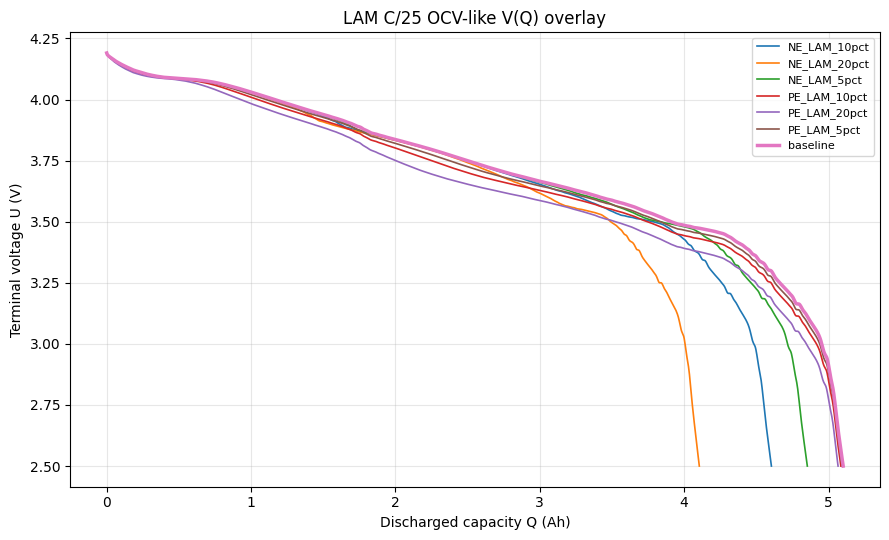

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/lam_fingerprint_c25_VQ_overlay.png


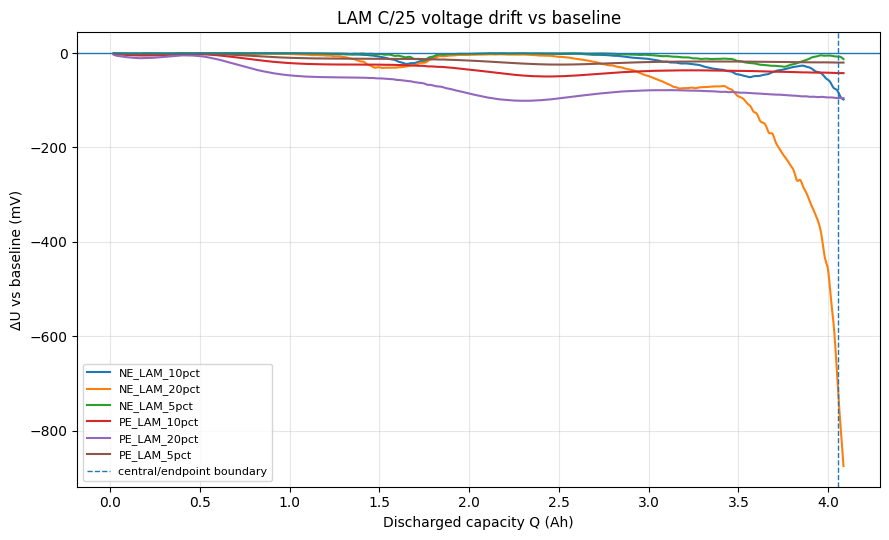

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/lam_fingerprint_c25_deltaU_vs_Q.png


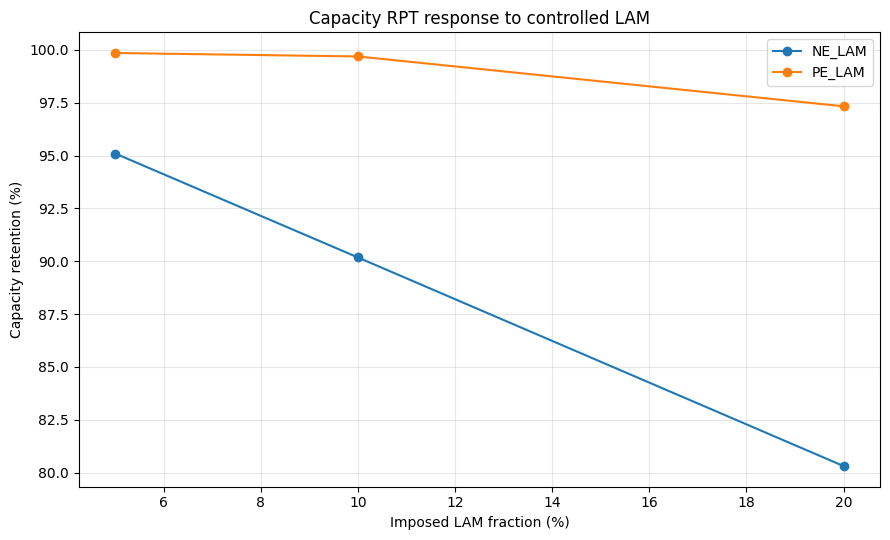

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/lam_fingerprint_capacity_retention.png


In [9]:
# Cell 9 — C/25 V(Q) visualization（C/25 电压曲线可视化）

# Figure 1 — V(Q) overlay by branch
plt.figure(figsize=(9, 5.5))
for condition, g in lam_c25_curve_table.groupby("condition"):
    if condition == "baseline":
        lw = 2.5
    else:
        lw = 1.2
    plt.plot(g["Q_dis_Ah"], g["U_V"], label=condition, linewidth=lw)

plt.xlabel("Discharged capacity Q (Ah)")
plt.ylabel("Terminal voltage U (V)")
plt.title("LAM C/25 OCV-like V(Q) overlay")
plt.grid(True, alpha=0.3)
plt.legend(fontsize=8)
plt.tight_layout()
p = FIGURES / "lam_fingerprint_c25_VQ_overlay.png"
plt.savefig(p, dpi=300)
plt.show()
print(f"[OK] saved: {p}")

# Figure 2 — central/full ΔU(Q)
plt.figure(figsize=(9, 5.5))
for condition, g in lam_c25_voltage_drift_curve.groupby("condition"):
    if condition == "baseline":
        continue
    plt.plot(g["Q_dis_Ah"], g["deltaU_vs_baseline_mV"], label=condition)

plt.axhline(0, linewidth=1)
plt.axvline(CENTRAL_Q_HI_AH_EFFECTIVE, linewidth=1, linestyle="--", label="central/endpoint boundary")
plt.xlabel("Discharged capacity Q (Ah)")
plt.ylabel("ΔU vs baseline (mV)")
plt.title("LAM C/25 voltage drift vs baseline")
plt.grid(True, alpha=0.3)
plt.legend(fontsize=8)
plt.tight_layout()
p = FIGURES / "lam_fingerprint_c25_deltaU_vs_Q.png"
plt.savefig(p, dpi=300)
plt.show()
print(f"[OK] saved: {p}")

# Figure 3 — capacity retention
plt.figure(figsize=(9, 5.5))
for branch, g in lam_capacity_rpt_table.groupby("branch"):
    if branch == "baseline":
        continue
    g = g.sort_values("LAM_fraction")
    plt.plot(
        g["LAM_fraction"] * 100,
        g["capacity_retention_pct"],
        marker="o",
        label=branch,
    )

plt.xlabel("Imposed LAM fraction (%)")
plt.ylabel("Capacity retention (%)")
plt.title("Capacity RPT response to controlled LAM")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
p = FIGURES / "lam_fingerprint_capacity_retention.png"
plt.savefig(p, dpi=300)
plt.show()
print(f"[OK] saved: {p}")

In [10]:
# Cell 10 — ICA/DVA extraction under controlled LAM
# （受控 LAM 下的 ICA/DVA 微分特征提取）

def smooth_centered(y, window):
    """Centered rolling mean smoothing with conservative edge fill."""
    s = pd.Series(y)
    return (
        s.rolling(window=window, center=True, min_periods=max(3, window // 5))
        .mean()
        .bfill()
        .ffill()
        .to_numpy()
    )


def extract_derivative_features(q, u, condition, branch, electrode, lam_fraction, smoothing_window, region_label, q_lo, q_hi):
    """
    Extract ICA/DVA features in a specified Q-window.

    ICA = Incremental Capacity Analysis（增量容量分析）
    DVA = Differential Voltage Analysis（微分电压分析）

    Discharge V(Q) has dV/dQ < 0.
    ICA magnitude = -dQ/dV = -1 / (dV/dQ)
    DVA magnitude = -dV/dQ
    """
    mask = (q >= q_lo) & (q <= q_hi)
    q_w = q[mask]
    u_w = u[mask]

    if len(q_w) < 20:
        raise RuntimeError(f"Too few points for {condition}, region={region_label}")

    u_smooth = smooth_centered(u_w, smoothing_window)
    dVdQ = np.gradient(u_smooth, q_w)

    dva_mag = -dVdQ

    with np.errstate(divide="ignore", invalid="ignore"):
        ica_mag = -1.0 / dVdQ

    valid = (
        np.isfinite(ica_mag)
        & np.isfinite(dva_mag)
        & (ica_mag > 0)
        & (dva_mag > 0)
    )

    if valid.sum() < 20:
        raise RuntimeError(f"Too few valid derivative points for {condition}, region={region_label}")

    ica_valid = np.where(valid, ica_mag, np.nan)
    dva_valid = np.where(valid, dva_mag, np.nan)

    i_peak = int(np.nanargmax(ica_valid))
    d_peak = int(np.nanargmax(dva_valid))

    return {
        "condition": condition,
        "branch": branch,
        "electrode": electrode,
        "LAM_fraction": float(lam_fraction),
        "smoothing_window": int(smoothing_window),
        "region": region_label,
        "q_lo_Ah": float(q_lo),
        "q_hi_Ah": float(q_hi),
        "n_points": int(len(q_w)),

        "ICA_peak_mag_Ah_per_V": float(ica_mag[i_peak]),
        "ICA_peak_Q_Ah": float(q_w[i_peak]),
        "ICA_peak_U_V": float(u_smooth[i_peak]),
        "ICA_median_Ah_per_V": float(np.nanmedian(ica_mag[valid])),
        "ICA_p95_Ah_per_V": float(np.nanpercentile(ica_mag[valid], 95)),

        "DVA_peak_mag_V_per_Ah": float(dva_mag[d_peak]),
        "DVA_peak_Q_Ah": float(q_w[d_peak]),
        "DVA_peak_U_V": float(u_smooth[d_peak]),
        "DVA_median_V_per_Ah": float(np.nanmedian(dva_mag[valid])),
        "DVA_p95_V_per_Ah": float(np.nanpercentile(dva_mag[valid], 95)),
    }


DERIVATIVE_REGIONS = {
    "full_common": (Q_GRID_LO_AH, Q_GRID_HI_AH),
    "central": (CENTRAL_Q_LO_AH, CENTRAL_Q_HI_AH_EFFECTIVE),
}

feature_rows = []
derivative_curve_rows = []

for condition, g in lam_c25_common_grid_table.groupby("condition"):
    g = g.sort_values("Q_dis_Ah").reset_index(drop=True)

    branch = g["branch"].iloc[0]
    electrode = g["electrode"].iloc[0]
    lam_fraction = float(g["LAM_fraction"].iloc[0])

    q = g["Q_dis_Ah"].to_numpy(dtype=float)
    u = g["U_interp_V"].to_numpy(dtype=float)

    for sw in SMOOTHING_WINDOWS:
        u_smooth_full = smooth_centered(u, sw)
        dVdQ_full = np.gradient(u_smooth_full, q)
        dva_full = -dVdQ_full

        with np.errstate(divide="ignore", invalid="ignore"):
            ica_full = -1.0 / dVdQ_full

        derivative_curve_rows.append(pd.DataFrame({
            "condition": condition,
            "branch": branch,
            "electrode": electrode,
            "LAM_fraction": lam_fraction,
            "smoothing_window": int(sw),
            "Q_dis_Ah": q,
            "U_smooth_V": u_smooth_full,
            "ICA_discharge_mag_Ah_per_V": ica_full,
            "DVA_discharge_mag_V_per_Ah": dva_full,
        }))

        for region_label, (q_lo, q_hi) in DERIVATIVE_REGIONS.items():
            feature_rows.append(
                extract_derivative_features(
                    q=q,
                    u=u,
                    condition=condition,
                    branch=branch,
                    electrode=electrode,
                    lam_fraction=lam_fraction,
                    smoothing_window=sw,
                    region_label=region_label,
                    q_lo=q_lo,
                    q_hi=q_hi,
                )
            )

lam_derivative_feature_table = pd.DataFrame(feature_rows)
lam_derivative_curve_table = pd.concat(derivative_curve_rows, ignore_index=True)

feature_path = DATA / "lam_fingerprint_derivative_feature_table.csv"
curve_path = DATA / "lam_fingerprint_derivative_curve_table.csv"

lam_derivative_feature_table.to_csv(feature_path, index=False)
lam_derivative_curve_table.to_csv(curve_path, index=False)

print(f"[OK] saved: {feature_path}")
print(f"[OK] saved: {curve_path}")

display(lam_derivative_feature_table.head(16))

print("[OK] LAM ICA/DVA feature extraction complete.")

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/lam_fingerprint_derivative_feature_table.csv
[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/lam_fingerprint_derivative_curve_table.csv


,condition,branch,electrode,LAM_fraction,smoothing_window,region,q_lo_Ah,q_hi_Ah,n_points,ICA_peak_mag_Ah_per_V,ICA_peak_Q_Ah,ICA_peak_U_V,ICA_median_Ah_per_V,ICA_p95_Ah_per_V,DVA_peak_mag_V_per_Ah,DVA_peak_Q_Ah,DVA_peak_U_V,DVA_median_V_per_Ah,DVA_p95_V_per_Ah
0,NE_LAM_10pct,NE_LAM,negative,0.1,21,full_common,0.02,4.085033,1500,28.049085,0.532536,4.084435,5.386104,17.726337,0.673579,4.038931,3.404326,0.185663,0.381666
1,NE_LAM_10pct,NE_LAM,negative,0.1,21,central,0.20,4.055033,1421,28.049085,0.532536,4.084435,5.453556,17.953758,0.582886,4.000966,3.426280,0.183367,0.314810
2,NE_LAM_10pct,NE_LAM,negative,0.1,41,full_common,0.02,4.085033,1500,26.953496,0.505417,4.085522,5.319758,17.558232,0.593045,4.019949,3.414924,0.187978,0.316804
3,NE_LAM_10pct,NE_LAM,negative,0.1,41,central,0.20,4.055033,1421,26.953496,0.505417,4.085522,5.335633,18.171309,0.488951,3.995542,3.428408,0.187419,0.282076
4,NE_LAM_10pct,NE_LAM,negative,0.1,81,full_common,0.02,4.085033,1500,22.005108,0.510841,4.085355,5.281559,15.544279,0.492511,3.968424,3.439009,0.189338,0.262657
5,NE_LAM_10pct,NE_LAM,negative,0.1,81,central,0.20,4.055033,1421,22.005108,0.510841,4.085355,5.291035,17.669868,0.424360,3.941306,3.451671,0.188999,0.256275
6,NE_LAM_10pct,NE_LAM,negative,0.1,121,full_common,0.02,4.085033,1500,19.180038,0.516265,4.085104,5.294634,13.917112,0.386329,3.919611,3.455940,0.188870,0.240425
7,NE_LAM_10pct,NE_LAM,negative,0.1,121,central,0.20,4.055033,1421,28.873239,0.361691,4.095776,5.302747,18.043679,0.329883,3.887069,3.467823,0.188582,0.239374
8,NE_LAM_20pct,NE_LAM,negative,0.2,21,full_common,0.02,4.085033,1500,30.549419,0.546095,4.083451,4.905417,16.565771,5.493842,4.055202,2.763456,0.203856,1.107468
9,NE_LAM_20pct,NE_LAM,negative,0.2,21,central,0.20,4.055033,1421,30.549419,0.546095,4.083451,5.040012,17.086876,4.425491,4.022660,2.928338,0.198412,1.000952


[OK] LAM ICA/DVA feature extraction complete.


In [11]:
# Cell 11 — LAM derivative signal vs smoothing sensitivity audit
# （LAM 微分特征信号与平滑敏感性对比审计）

FEATURES_TO_AUDIT = [
    "ICA_peak_mag_Ah_per_V",
    "ICA_peak_Q_Ah",
    "ICA_median_Ah_per_V",
    "DVA_peak_mag_V_per_Ah",
    "DVA_peak_Q_Ah",
    "DVA_median_V_per_Ah",
]

# Baseline feature values by smoothing window and region
baseline_features = lam_derivative_feature_table[
    lam_derivative_feature_table["condition"] == "baseline"
].copy()

signal_rows = []

for _, row in lam_derivative_feature_table.iterrows():
    condition = row["condition"]

    if condition == "baseline":
        continue

    branch = row["branch"]
    lam_fraction = float(row["LAM_fraction"])
    region = row["region"]
    sw = int(row["smoothing_window"])

    base = baseline_features[
        (baseline_features["region"] == region)
        & (baseline_features["smoothing_window"] == sw)
    ]

    if base.empty:
        raise RuntimeError(f"Missing baseline for region={region}, smoothing={sw}")

    base = base.iloc[0]

    out = {
        "condition": condition,
        "branch": branch,
        "electrode": row["electrode"],
        "LAM_fraction": lam_fraction,
        "region": region,
        "smoothing_window": sw,
    }

    for feat in FEATURES_TO_AUDIT:
        signal = float(row[feat] - base[feat])
        out[f"{feat}_signal_vs_baseline"] = signal
        out[f"{feat}_abs_signal_vs_baseline"] = abs(signal)

    signal_rows.append(out)

lam_derivative_signal_by_smoothing = pd.DataFrame(signal_rows)

# Summarize signal and smoothing sensitivity by condition/region
summary_rows = []

for (condition, region), g in lam_derivative_signal_by_smoothing.groupby(["condition", "region"]):
    meta = g.iloc[0][["branch", "electrode", "LAM_fraction"]].to_dict()

    out = {
        "condition": condition,
        **meta,
        "region": region,
    }

    for feat in FEATURES_TO_AUDIT:
        sig = g[f"{feat}_signal_vs_baseline"].to_numpy(dtype=float)
        abs_sig = np.abs(sig)

        out[f"{feat}_signal_mean"] = float(np.mean(sig))
        out[f"{feat}_signal_abs_mean"] = float(np.mean(abs_sig))
        out[f"{feat}_signal_range_across_smoothing"] = float(np.max(sig) - np.min(sig))
        out[f"{feat}_signal_abs_range_across_smoothing"] = float(np.max(abs_sig) - np.min(abs_sig))

        denom = out[f"{feat}_signal_abs_range_across_smoothing"]
        out[f"{feat}_signal_to_smoothing_range_ratio"] = (
            out[f"{feat}_signal_abs_mean"] / denom if denom > 1e-12 else np.inf
        )

        # Direction consistency across smoothing windows
        signs = np.sign(sig[np.abs(sig) > 1e-12])
        if len(signs) == 0:
            direction_consistency = np.nan
        else:
            direction_consistency = float(max(np.mean(signs > 0), np.mean(signs < 0)))

        out[f"{feat}_direction_consistency"] = direction_consistency

    summary_rows.append(out)

lam_derivative_signal_audit = pd.DataFrame(summary_rows)

signal_raw_path = DATA / "lam_fingerprint_derivative_signal_by_smoothing.csv"
signal_summary_path = DATA / "lam_fingerprint_derivative_signal_audit.csv"

lam_derivative_signal_by_smoothing.to_csv(signal_raw_path, index=False)
lam_derivative_signal_audit.to_csv(signal_summary_path, index=False)

print(f"[OK] saved: {signal_raw_path}")
print(f"[OK] saved: {signal_summary_path}")

display(lam_derivative_signal_audit[[
    "condition", "branch", "LAM_fraction", "region",
    "ICA_peak_Q_Ah_signal_to_smoothing_range_ratio",
    "ICA_peak_Q_Ah_direction_consistency",
    "ICA_peak_mag_Ah_per_V_signal_to_smoothing_range_ratio",
    "DVA_median_V_per_Ah_signal_to_smoothing_range_ratio",
    "DVA_peak_mag_V_per_Ah_signal_to_smoothing_range_ratio",
]].sort_values(["branch", "LAM_fraction", "region"]))

print("[OK] LAM derivative signal vs smoothing sensitivity audit complete.")

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/lam_fingerprint_derivative_signal_by_smoothing.csv
[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/lam_fingerprint_derivative_signal_audit.csv


,condition,branch,LAM_fraction,region,ICA_peak_Q_Ah_signal_to_smoothing_range_ratio,ICA_peak_Q_Ah_direction_consistency,ICA_peak_mag_Ah_per_V_signal_to_smoothing_range_ratio,DVA_median_V_per_Ah_signal_to_smoothing_range_ratio,DVA_peak_mag_V_per_Ah_signal_to_smoothing_range_ratio
4,NE_LAM_5pct,NE_LAM,0.05,central,0.517857,0.666667,0.394055,0.952838,1.866113
5,NE_LAM_5pct,NE_LAM,0.05,full_common,0.825000,0.750000,0.423232,0.631117,0.420859
0,NE_LAM_10pct,NE_LAM,0.10,central,0.600000,1.000000,0.489886,2.770644,1.126649
1,NE_LAM_10pct,NE_LAM,0.10,full_common,0.785714,0.750000,0.639615,2.617957,1.663319
2,NE_LAM_20pct,NE_LAM,0.20,central,0.600000,1.000000,0.468698,4.268932,0.987816
3,NE_LAM_20pct,NE_LAM,0.20,full_common,0.676471,0.750000,0.429933,9.326547,1.059820
10,PE_LAM_5pct,PE_LAM,0.05,central,0.427083,1.000000,0.588545,3.163418,1.451688
11,PE_LAM_5pct,PE_LAM,0.05,full_common,0.485294,1.000000,0.610686,2.137640,0.712686
6,PE_LAM_10pct,PE_LAM,0.10,central,0.444444,1.000000,0.681740,13.390737,1.928254
7,PE_LAM_10pct,PE_LAM,0.10,full_common,0.674242,1.000000,0.729128,26.612692,0.681078


[OK] LAM derivative signal vs smoothing sensitivity audit complete.


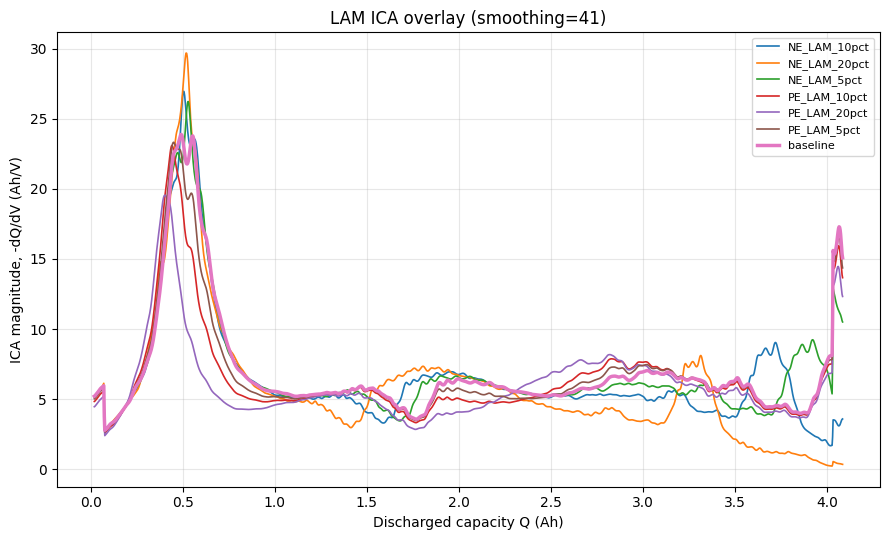

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/lam_fingerprint_ica_overlay.png


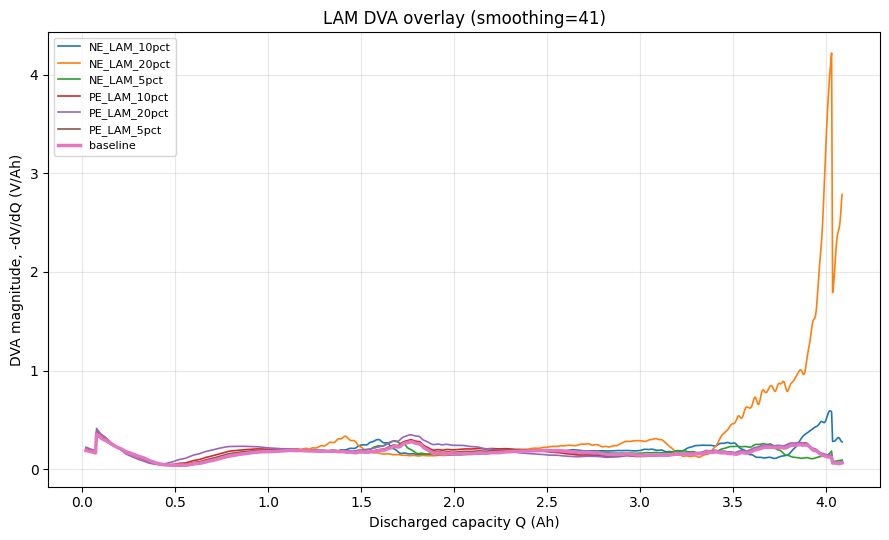

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/lam_fingerprint_dva_overlay.png
[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/lam_fingerprint_derivative_feature_classification.csv


,condition,branch,LAM_fraction,region,feature,signal_to_smoothing_range_ratio,direction_consistency,classification
18,NE_LAM_5pct,NE_LAM,0.05,central,DVA_median_V_per_Ah,0.952838,1.000000,not reliable as primary fitting target
19,NE_LAM_5pct,NE_LAM,0.05,central,DVA_peak_mag_V_per_Ah,1.866113,1.000000,conditional auxiliary target
16,NE_LAM_5pct,NE_LAM,0.05,central,ICA_peak_Q_Ah,0.517857,0.666667,not reliable as primary fitting target
17,NE_LAM_5pct,NE_LAM,0.05,central,ICA_peak_mag_Ah_per_V,0.394055,0.750000,not reliable as primary fitting target
22,NE_LAM_5pct,NE_LAM,0.05,full_common,DVA_median_V_per_Ah,0.631117,1.000000,not reliable as primary fitting target
23,NE_LAM_5pct,NE_LAM,0.05,full_common,DVA_peak_mag_V_per_Ah,0.420859,0.500000,not reliable as primary fitting target
20,NE_LAM_5pct,NE_LAM,0.05,full_common,ICA_peak_Q_Ah,0.825000,0.750000,not reliable as primary fitting target
21,NE_LAM_5pct,NE_LAM,0.05,full_common,ICA_peak_mag_Ah_per_V,0.423232,0.750000,not reliable as primary fitting target
2,NE_LAM_10pct,NE_LAM,0.10,central,DVA_median_V_per_Ah,2.770644,1.000000,candidate fitting target
3,NE_LAM_10pct,NE_LAM,0.10,central,DVA_peak_mag_V_per_Ah,1.126649,1.000000,conditional auxiliary target


[OK] LAM derivative feature classification complete.


In [12]:
# Cell 12 — LAM ICA/DVA plots and provisional feature classification
# （LAM ICA/DVA 图像与初步特征分类）

ref_curves = lam_derivative_curve_table[
    lam_derivative_curve_table["smoothing_window"] == REF_SMOOTHING_WINDOW
].copy()

# Figure 1 — ICA overlay
plt.figure(figsize=(9, 5.5))
for condition, g in ref_curves.groupby("condition"):
    lw = 2.5 if condition == "baseline" else 1.2
    plt.plot(
        g["Q_dis_Ah"],
        g["ICA_discharge_mag_Ah_per_V"],
        label=condition,
        linewidth=lw,
    )

plt.xlabel("Discharged capacity Q (Ah)")
plt.ylabel("ICA magnitude, -dQ/dV (Ah/V)")
plt.title(f"LAM ICA overlay (smoothing={REF_SMOOTHING_WINDOW})")
plt.grid(True, alpha=0.3)
plt.legend(fontsize=8)
plt.tight_layout()
p = FIGURES / "lam_fingerprint_ica_overlay.png"
plt.savefig(p, dpi=300)
plt.show()
print(f"[OK] saved: {p}")

# Figure 2 — DVA overlay
plt.figure(figsize=(9, 5.5))
for condition, g in ref_curves.groupby("condition"):
    lw = 2.5 if condition == "baseline" else 1.2
    plt.plot(
        g["Q_dis_Ah"],
        g["DVA_discharge_mag_V_per_Ah"],
        label=condition,
        linewidth=lw,
    )

plt.xlabel("Discharged capacity Q (Ah)")
plt.ylabel("DVA magnitude, -dV/dQ (V/Ah)")
plt.title(f"LAM DVA overlay (smoothing={REF_SMOOTHING_WINDOW})")
plt.grid(True, alpha=0.3)
plt.legend(fontsize=8)
plt.tight_layout()
p = FIGURES / "lam_fingerprint_dva_overlay.png"
plt.savefig(p, dpi=300)
plt.show()
print(f"[OK] saved: {p}")

# Classification of derivative feature suitability
classification_rows = []

for _, row in lam_derivative_signal_audit.iterrows():
    condition = row["condition"]
    branch = row["branch"]
    lam_fraction = float(row["LAM_fraction"])
    region = row["region"]

    for feat in [
        "ICA_peak_Q_Ah",
        "ICA_peak_mag_Ah_per_V",
        "DVA_median_V_per_Ah",
        "DVA_peak_mag_V_per_Ah",
    ]:
        ratio = float(row[f"{feat}_signal_to_smoothing_range_ratio"])
        direction = float(row[f"{feat}_direction_consistency"])

        if np.isinf(ratio) and direction >= 0.75:
            cls = "candidate fitting target"
        elif ratio >= 2.0 and direction >= 0.75:
            cls = "candidate fitting target"
        elif ratio >= 1.0 and direction >= 0.75:
            cls = "conditional auxiliary target"
        else:
            cls = "not reliable as primary fitting target"

        classification_rows.append({
            "condition": condition,
            "branch": branch,
            "LAM_fraction": lam_fraction,
            "region": region,
            "feature": feat,
            "signal_to_smoothing_range_ratio": ratio,
            "direction_consistency": direction,
            "classification": cls,
        })

lam_derivative_feature_classification = pd.DataFrame(classification_rows)

feature_class_path = DATA / "lam_fingerprint_derivative_feature_classification.csv"
lam_derivative_feature_classification.to_csv(feature_class_path, index=False)

print(f"[OK] saved: {feature_class_path}")

display(lam_derivative_feature_classification.sort_values([
    "branch", "LAM_fraction", "region", "feature"
]))

print("[OK] LAM derivative feature classification complete.")

In [13]:
# Cell 13 — LAM fingerprint classification and fitting-target hierarchy
# （LAM 机制指纹分类与拟合目标层级）

# --- Helper: summarize capacity branch ---

capacity_summary_rows = []

for branch in ["NE_LAM", "PE_LAM"]:
    g = lam_capacity_rpt_table[lam_capacity_rpt_table["branch"] == branch].copy()
    g = g.sort_values("LAM_fraction")

    if g.empty:
        continue

    cap_loss_20 = float(
        g.loc[g["LAM_fraction"] == 0.20, "capacity_loss_pct_vs_baseline"].iloc[0]
    ) if (g["LAM_fraction"] == 0.20).any() else np.nan

    q_loss_20 = float(
        g.loc[g["LAM_fraction"] == 0.20, "capacity_loss_Ah_vs_baseline"].iloc[0]
    ) if (g["LAM_fraction"] == 0.20).any() else np.nan

    cap_loss_values = g["capacity_loss_pct_vs_baseline"].to_numpy(dtype=float)
    lam_values = g["LAM_fraction"].to_numpy(dtype=float)

    monotonic_capacity_loss = bool(np.all(np.diff(cap_loss_values) >= -1e-9))

    capacity_summary_rows.append({
        "branch": branch,
        "capacity_loss_20pct_pct": cap_loss_20,
        "capacity_loss_20pct_Ah": q_loss_20,
        "capacity_loss_monotonic_with_LAM": monotonic_capacity_loss,
        "capacity_role": (
            "primary target" if cap_loss_20 >= 5
            else "secondary / weak target" if cap_loss_20 >= 1
            else "weak boundary-level target"
        ),
    })

lam_capacity_summary = pd.DataFrame(capacity_summary_rows)


# --- Helper: summarize C/25 central V(Q) branch ---

vq_summary_rows = []

for branch in ["NE_LAM", "PE_LAM"]:
    g = lam_c25_voltage_drift_audit[lam_c25_voltage_drift_audit["branch"] == branch].copy()
    g = g.sort_values("LAM_fraction")

    if g.empty:
        continue

    central_20 = float(
        g.loc[g["LAM_fraction"] == 0.20, "central_deltaU_mean_mV"].iloc[0]
    ) if (g["LAM_fraction"] == 0.20).any() else np.nan

    central_p95_20 = float(
        g.loc[g["LAM_fraction"] == 0.20, "central_deltaU_p95_abs_mV"].iloc[0]
    ) if (g["LAM_fraction"] == 0.20).any() else np.nan

    endpoint_flag_any = bool(g["endpoint_amplification_flag"].any())

    central_vals = g["central_deltaU_mean_mV"].to_numpy(dtype=float)

    # For LAM here, stronger LAM should generally make central ΔU more negative
    central_monotonic_negative = bool(np.all(np.diff(central_vals) <= 1e-9))

    vq_summary_rows.append({
        "branch": branch,
        "central_deltaU_20pct_mean_mV": central_20,
        "central_deltaU_20pct_p95_abs_mV": central_p95_20,
        "central_deltaU_monotonic_negative": central_monotonic_negative,
        "endpoint_amplification_any": endpoint_flag_any,
        "C25_central_VQ_role": (
            "candidate fitting target" if abs(central_20) >= 20 and not endpoint_flag_any
            else "conditional target with boundary control" if abs(central_20) >= 10
            else "secondary weak voltage target"
        ),
    })

lam_vq_summary = pd.DataFrame(vq_summary_rows)


# --- Helper: summarize derivative features ---

# Count candidate / auxiliary targets by branch, region and feature
deriv_summary_rows = []

for branch in ["NE_LAM", "PE_LAM"]:
    g = lam_derivative_feature_classification[lam_derivative_feature_classification["branch"] == branch].copy()

    if g.empty:
        continue

    central = g[g["region"] == "central"].copy()

    n_central_candidates = int((central["classification"] == "candidate fitting target").sum())
    n_central_aux = int((central["classification"] == "conditional auxiliary target").sum())

    # Focus on DVA median because it is the strongest and most stable in the current outputs
    dva_median_central = central[central["feature"] == "DVA_median_V_per_Ah"].copy()

    candidate_conditions = (
        dva_median_central[dva_median_central["classification"] == "candidate fitting target"]
        ["condition"]
        .tolist()
    )

    max_ratio = float(dva_median_central["signal_to_smoothing_range_ratio"].max())
    min_direction = float(dva_median_central["direction_consistency"].min())

    deriv_summary_rows.append({
        "branch": branch,
        "central_candidate_count": n_central_candidates,
        "central_auxiliary_count": n_central_aux,
        "DVA_median_central_candidate_conditions": "; ".join(candidate_conditions),
        "DVA_median_central_max_signal_to_smoothing_ratio": max_ratio,
        "DVA_median_central_min_direction_consistency": min_direction,
        "ICA_DVA_central_role": (
            "candidate fitting target" if n_central_candidates >= 2
            else "conditional auxiliary target" if n_central_candidates + n_central_aux >= 2
            else "auxiliary audit only"
        ),
    })

lam_derivative_summary = pd.DataFrame(deriv_summary_rows)


# --- Combine summaries ---

lam_branch_summary = (
    lam_capacity_summary
    .merge(lam_vq_summary, on="branch", how="outer")
    .merge(lam_derivative_summary, on="branch", how="outer")
)

branch_summary_path = DATA / "lam_fingerprint_branch_summary.csv"
lam_branch_summary.to_csv(branch_summary_path, index=False)

print(f"[OK] saved: {branch_summary_path}")
display(lam_branch_summary)


# --- Build Mechanism Fingerprint Registry v0.2 row for LAM ---

def get_branch_row(df, branch):
    return df[df["branch"] == branch].iloc[0].to_dict()


ne = get_branch_row(lam_branch_summary, "NE_LAM")
pe = get_branch_row(lam_branch_summary, "PE_LAM")

lam_fingerprint_summary = pd.DataFrame([
    {
        "mechanism": "NE_LAM_controlled_active_material_loss",
        "capacity_RPT": (
            f"strong capacity loss; 20% NE-LAM capacity loss = "
            f"{ne['capacity_loss_20pct_pct']:.2f}% "
            f"({ne['capacity_loss_20pct_Ah']:.6f} Ah)"
        ),
        "Ri_0.05s": "not audited in this notebook",
        "Ri_0.1s": "not audited in this notebook",
        "Ri_1s": "not audited in this notebook",
        "Ri_10s": "not audited in this notebook",
        "Ri_recovery_0.1s": "not audited in this notebook",
        "Ri_recovery_1s": "not audited in this notebook",
        "tau_FG_eff": "not audited in this notebook",
        "t95": "not audited in this notebook",
        "t99": "not audited in this notebook",
        "tau_tail": "not audited in this notebook",
        "recovery_amplitude": "not audited in this notebook",
        "recovery_area": "not audited in this notebook",
        "C25_central_VQ": (
            f"strong but boundary-sensitive; 20% central mean ΔU = "
            f"{ne['central_deltaU_20pct_mean_mV']:.2f} mV; "
            f"endpoint amplification any = {ne['endpoint_amplification_any']}"
        ),
        "GITT_finite_rest": "not audited in this notebook",
        "ICA_DVA_central": (
            f"DVA central features partly upgraded; candidate conditions: "
            f"{ne['DVA_median_central_candidate_conditions']}"
        ),
        "endpoint_boundary": (
            "NE-LAM 10% and 20% show endpoint amplification / boundary sensitivity"
            if ne["endpoint_amplification_any"] else
            "no dominant endpoint amplification"
        ),
        "best_fitting_targets": (
            "capacity_RPT primary; C25_central_VQ and DVA_median central as secondary/conditional targets"
        ),
        "rejection_flags": (
            "NE-LAM 20% is a stress/boundary case; endpoint-amplified full-window interpretation rejected"
        ),
    },
    {
        "mechanism": "PE_LAM_controlled_active_material_loss",
        "capacity_RPT": (
            f"weak-to-moderate capacity loss; 20% PE-LAM capacity loss = "
            f"{pe['capacity_loss_20pct_pct']:.2f}% "
            f"({pe['capacity_loss_20pct_Ah']:.6f} Ah)"
        ),
        "Ri_0.05s": "not audited in this notebook",
        "Ri_0.1s": "not audited in this notebook",
        "Ri_1s": "not audited in this notebook",
        "Ri_10s": "not audited in this notebook",
        "Ri_recovery_0.1s": "not audited in this notebook",
        "Ri_recovery_1s": "not audited in this notebook",
        "tau_FG_eff": "not audited in this notebook",
        "t95": "not audited in this notebook",
        "t99": "not audited in this notebook",
        "tau_tail": "not audited in this notebook",
        "recovery_amplitude": "not audited in this notebook",
        "recovery_area": "not audited in this notebook",
        "C25_central_VQ": (
            f"strong voltage-shape target; 20% central mean ΔU = "
            f"{pe['central_deltaU_20pct_mean_mV']:.2f} mV; "
            f"endpoint amplification any = {pe['endpoint_amplification_any']}"
        ),
        "GITT_finite_rest": "not audited in this notebook",
        "ICA_DVA_central": (
            f"DVA central features are candidate fitting targets; candidate conditions: "
            f"{pe['DVA_median_central_candidate_conditions']}"
        ),
        "endpoint_boundary": (
            "no dominant endpoint amplification in tested PE-LAM branch"
            if not pe["endpoint_amplification_any"] else
            "endpoint amplification detected"
        ),
        "best_fitting_targets": (
            "C25_central_VQ and DVA_median central primary/secondary targets; capacity_RPT auxiliary"
        ),
        "rejection_flags": (
            "ICA peak magnitude mostly rejected due to smoothing sensitivity; use DVA central features preferentially"
        ),
    }
])

lam_fingerprint_summary_path = DATA / "lam_fingerprint_summary_v0_2.csv"
lam_fingerprint_summary.to_csv(lam_fingerprint_summary_path, index=False)

print(f"[OK] saved: {lam_fingerprint_summary_path}")
display(lam_fingerprint_summary)


# --- Classification table ---

lam_classification_table = pd.DataFrame([
    {
        "metric_layer": "capacity_RPT",
        "evidence": (
            "NE-LAM shows strong monotonic capacity loss up to ~19.69% at 20% LAM; "
            "PE-LAM shows weaker capacity loss up to ~2.67% at 20% LAM."
        ),
        "strength": "strong for NE-LAM; moderate for PE-LAM",
        "classification": "capacity RPT separates NE-LAM and PE-LAM response patterns",
    },
    {
        "metric_layer": "C25_central_VQ",
        "evidence": (
            "PE-LAM shows large central-window V(Q) drift without endpoint amplification; "
            "NE-LAM shows strong drift but becomes endpoint/boundary sensitive at 10–20%."
        ),
        "strength": "strong",
        "classification": "LAM produces stronger voltage-shape fingerprints than SEI-only aging",
    },
    {
        "metric_layer": "ICA_DVA_central",
        "evidence": (
            "DVA_median central features pass signal-to-smoothing criteria for multiple LAM cases; "
            "ICA features remain mostly unreliable except selected boundary-sensitive cases."
        ),
        "strength": "supported for DVA; weak for ICA",
        "classification": "DVA central features are candidate fitting targets for LAM, especially PE-LAM",
    },
    {
        "metric_layer": "endpoint_boundary",
        "evidence": (
            "NE-LAM 10% and 20% show endpoint amplification; PE-LAM does not show dominant endpoint amplification."
        ),
        "strength": "critical boundary",
        "classification": "NE-LAM high-severity cases require boundary-control interpretation",
    },
    {
        "metric_layer": "overall",
        "evidence": (
            "Controlled LAM produces clear capacity, voltage-shape, and DVA fingerprints that differ from "
            "both SEI-only aging and contact resistance growth."
        ),
        "strength": "supported",
        "classification": (
            "LAM fingerprint is capacity- and voltage-shape-sensitive; "
            "PE-LAM is especially suitable for C25 V(Q) and DVA-based fitting targets"
        ),
    },
])

classification_path = DATA / "lam_fingerprint_classification_table.csv"
lam_classification_table.to_csv(classification_path, index=False)

print(f"[OK] saved: {classification_path}")
display(lam_classification_table)

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/lam_fingerprint_branch_summary.csv


,branch,capacity_loss_20pct_pct,capacity_loss_20pct_Ah,capacity_loss_monotonic_with_LAM,capacity_role,central_deltaU_20pct_mean_mV,central_deltaU_20pct_p95_abs_mV,central_deltaU_monotonic_negative,endpoint_amplification_any,C25_central_VQ_role,central_candidate_count,central_auxiliary_count,DVA_median_central_candidate_conditions,DVA_median_central_max_signal_to_smoothing_ratio,DVA_median_central_min_direction_consistency,ICA_DVA_central_role
0,NE_LAM,19.686244,0.994110,True,primary target,-54.104971,283.049269,True,True,conditional target with boundary control,2,2,NE_LAM_10pct; NE_LAM_20pct,4.268932,1.0,candidate fitting target
1,PE_LAM,2.673562,0.135009,True,secondary / weak target,-66.417530,99.555375,True,False,candidate fitting target,4,2,PE_LAM_10pct; PE_LAM_20pct; PE_LAM_5pct,13.390737,1.0,candidate fitting target


[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/lam_fingerprint_summary_v0_2.csv


,mechanism,capacity_RPT,Ri_0.05s,Ri_0.1s,Ri_1s,Ri_10s,Ri_recovery_0.1s,Ri_recovery_1s,tau_FG_eff,t95,t99,tau_tail,recovery_amplitude,recovery_area,C25_central_VQ,GITT_finite_rest,ICA_DVA_central,endpoint_boundary,best_fitting_targets,rejection_flags
0,NE_LAM_controlled_active_material_loss,strong capacity loss; 20% NE-LAM capacity loss...,not audited in this notebook,not audited in this notebook,not audited in this notebook,not audited in this notebook,not audited in this notebook,not audited in this notebook,not audited in this notebook,not audited in this notebook,not audited in this notebook,not audited in this notebook,not audited in this notebook,not audited in this notebook,strong but boundary-sensitive; 20% central mea...,not audited in this notebook,DVA central features partly upgraded; candidat...,NE-LAM 10% and 20% show endpoint amplification...,capacity_RPT primary; C25_central_VQ and DVA_m...,NE-LAM 20% is a stress/boundary case; endpoint...
1,PE_LAM_controlled_active_material_loss,weak-to-moderate capacity loss; 20% PE-LAM cap...,not audited in this notebook,not audited in this notebook,not audited in this notebook,not audited in this notebook,not audited in this notebook,not audited in this notebook,not audited in this notebook,not audited in this notebook,not audited in this notebook,not audited in this notebook,not audited in this notebook,not audited in this notebook,strong voltage-shape target; 20% central mean ...,not audited in this notebook,DVA central features are candidate fitting tar...,no dominant endpoint amplification in tested P...,C25_central_VQ and DVA_median central primary/...,ICA peak magnitude mostly rejected due to smoo...


[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/lam_fingerprint_classification_table.csv


,metric_layer,evidence,strength,classification
0,capacity_RPT,NE-LAM shows strong monotonic capacity loss up...,strong for NE-LAM; moderate for PE-LAM,capacity RPT separates NE-LAM and PE-LAM respo...
1,C25_central_VQ,PE-LAM shows large central-window V(Q) drift w...,strong,LAM produces stronger voltage-shape fingerprin...
2,ICA_DVA_central,DVA_median central features pass signal-to-smo...,supported for DVA; weak for ICA,DVA central features are candidate fitting tar...
3,endpoint_boundary,NE-LAM 10% and 20% show endpoint amplification...,critical boundary,NE-LAM high-severity cases require boundary-co...
4,overall,"Controlled LAM produces clear capacity, voltag...",supported,LAM fingerprint is capacity- and voltage-shape...


In [14]:
# Cell 14 — Notebook 24 output inventory audit（Notebook 24 输出文件清单审计）

expected_outputs = [
    DATA / "lam_fingerprint_branch_contract.csv",
    DATA / "lam_fingerprint_parameter_audit.csv",
    DATA / "lam_fingerprint_capacity_segment_audit.csv",
    DATA / "lam_fingerprint_capacity_selected_segment_audit.csv",
    DATA / "lam_fingerprint_capacity_rpt_table.csv",
    DATA / "lam_fingerprint_c25_segment_audit.csv",
    DATA / "lam_fingerprint_c25_selected_segment_audit.csv",
    DATA / "lam_fingerprint_c25_curve_table.csv",
    DATA / "lam_fingerprint_c25_curve_summary.csv",
    DATA / "lam_fingerprint_c25_quality_audit.csv",
    DATA / "lam_fingerprint_c25_common_grid_table.csv",
    DATA / "lam_fingerprint_c25_voltage_drift_audit.csv",
    DATA / "lam_fingerprint_c25_voltage_drift_curve.csv",
    DATA / "lam_fingerprint_derivative_feature_table.csv",
    DATA / "lam_fingerprint_derivative_curve_table.csv",
    DATA / "lam_fingerprint_derivative_signal_by_smoothing.csv",
    DATA / "lam_fingerprint_derivative_signal_audit.csv",
    DATA / "lam_fingerprint_derivative_feature_classification.csv",
    DATA / "lam_fingerprint_branch_summary.csv",
    DATA / "lam_fingerprint_summary_v0_2.csv",
    DATA / "lam_fingerprint_classification_table.csv",

    FIGURES / "lam_fingerprint_c25_VQ_overlay.png",
    FIGURES / "lam_fingerprint_c25_deltaU_vs_Q.png",
    FIGURES / "lam_fingerprint_capacity_retention.png",
    FIGURES / "lam_fingerprint_ica_overlay.png",
    FIGURES / "lam_fingerprint_dva_overlay.png",
]

inventory_rows = []

for p in expected_outputs:
    inventory_rows.append({
        "path": str(p.relative_to(REPO)),
        "exists": p.exists(),
        "size_kB": round(p.stat().st_size / 1024, 2) if p.exists() else np.nan,
    })

output_inventory = pd.DataFrame(inventory_rows)

inventory_path = DATA / "lam_fingerprint_output_inventory.csv"
output_inventory.to_csv(inventory_path, index=False)

print(f"[OK] saved: {inventory_path}")
display(output_inventory)

assert output_inventory["exists"].all(), "Some expected Notebook 24 outputs are missing."
print("[OK] All expected Notebook 24 outputs exist.")

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/lam_fingerprint_output_inventory.csv


,path,exists,size_kB
0,data/lam_fingerprint_branch_contract.csv,True,0.71
1,data/lam_fingerprint_parameter_audit.csv,True,0.67
2,data/lam_fingerprint_capacity_segment_audit.csv,True,2.45
3,data/lam_fingerprint_capacity_selected_segment...,True,1.41
4,data/lam_fingerprint_capacity_rpt_table.csv,True,1.41
5,data/lam_fingerprint_c25_segment_audit.csv,True,2.50
6,data/lam_fingerprint_c25_selected_segment_audi...,True,1.62
7,data/lam_fingerprint_c25_curve_table.csv,True,1124.96
8,data/lam_fingerprint_c25_curve_summary.csv,True,1.02
9,data/lam_fingerprint_c25_quality_audit.csv,True,1.43


[OK] All expected Notebook 24 outputs exist.


## Final closure — Notebook 24

### Key findings

Notebook 24 audited whether controlled LAM (Loss of Active Material, 活性材料损失) produces a diagnostic fingerprint that is separable from both SEI-only aging and contact / ohmic resistance growth.

This notebook used a controlled active-material volume-fraction perturbation rather than a dynamic LAM aging pathway.

Controlled LAM levels:

- 5%,
- 10%,
- 20%.

Branches:

- NE-LAM (Negative Electrode Loss of Active Material, 负极活性材料损失),
- PE-LAM (Positive Electrode Loss of Active Material, 正极活性材料损失).

The notebook reused Mechanism Fingerprint Registry v0.2 and audited:

1. Capacity RPT (Reference Performance Test, 基准性能测试),
2. C/25 OCV-like V(Q) (C/25 近似 OCV 电压曲线),
3. central-window voltage drift (中央窗口电压漂移),
4. ICA/DVA central features (中央窗口微分电压特征),
5. endpoint / boundary behavior (端点 / 边界行为),
6. fitting-target hierarchy (拟合目标层级).

### Capacity RPT response

NE-LAM produced a strong and monotonic capacity-loss fingerprint:

- NE-LAM 5%: capacity retention ≈ 95.09%;
- NE-LAM 10%: capacity retention ≈ 90.18%;
- NE-LAM 20%: capacity retention ≈ 80.31%.

At 20% NE-LAM, capacity loss reached approximately:

- 19.69%,
- 0.994110 Ah.

PE-LAM produced a weaker capacity response:

- PE-LAM 5%: capacity retention ≈ 99.85%;
- PE-LAM 10%: capacity retention ≈ 99.68%;
- PE-LAM 20%: capacity retention ≈ 97.33%.

At 20% PE-LAM, capacity loss reached approximately:

- 2.67%,
- 0.135009 Ah.

Therefore, capacity RPT separates NE-LAM and PE-LAM response patterns. NE-LAM is capacity-dominant, whereas PE-LAM is not primarily capacity-dominant in the tested range.

### C/25 OCV-like V(Q)

All C/25 OCV-like V(Q) curves passed the quality audit.

The common-Q window was limited by the most capacity-reduced condition, NE-LAM 20%:

- common Q upper bound ≈ 4.105 Ah,
- effective central window = 0.20–4.055 Ah.

PE-LAM produced strong central-window voltage-shape drift without dominant endpoint amplification:

- PE-LAM 5%: central mean ΔU ≈ −14.63 mV;
- PE-LAM 10%: central mean ΔU ≈ −30.43 mV;
- PE-LAM 20%: central mean ΔU ≈ −66.42 mV;
- endpoint amplification flag = False.

This indicates that PE-LAM produces a genuine voltage-shape fingerprint rather than an endpoint-only signal.

NE-LAM also produced strong V(Q) drift, but higher-severity NE-LAM became boundary-sensitive:

- NE-LAM 5%: central mean ΔU ≈ −5.16 mV, endpoint flag = False;
- NE-LAM 10%: central mean ΔU ≈ −12.35 mV, endpoint flag = True;
- NE-LAM 20%: central mean ΔU ≈ −54.10 mV, endpoint flag = True.

Therefore, NE-LAM 10% and 20% require endpoint / boundary-control interpretation.

### ICA/DVA derivative features

ICA (Incremental Capacity Analysis, 增量容量分析) and DVA (Differential Voltage Analysis, 微分电压分析) were extracted across smoothing windows and evaluated using signal-to-smoothing sensitivity.

The main result is that DVA central features are substantially more informative under LAM than under SEI-only aging.

For DVA_median in the central region:

- NE-LAM 10%: signal-to-smoothing ratio ≈ 2.77;
- NE-LAM 20%: signal-to-smoothing ratio ≈ 4.27;
- PE-LAM 5%: signal-to-smoothing ratio ≈ 3.16;
- PE-LAM 10%: signal-to-smoothing ratio ≈ 13.39;
- PE-LAM 20%: signal-to-smoothing ratio ≈ 10.36.

These values exceed the primary threshold of 2 for multiple LAM cases and show direction consistency of 1.0.

In contrast, most ICA peak-Q and ICA peak-magnitude features remained below the reliability threshold or were more sensitive to smoothing and boundary effects.

Thus:

- DVA central features are candidate fitting targets for LAM, especially PE-LAM.
- ICA features remain mostly auxiliary or unreliable as primary fitting targets.

### Branch-level fingerprint classification

NE-LAM is classified as:

`capacity-dominant + boundary-sensitive LAM fingerprint`

Main targets:

- capacity RPT as primary target;
- C/25 central V(Q) as secondary / conditional target;
- DVA_median central as secondary / candidate target;
- endpoint features only with boundary control.

NE-LAM 20% should be treated as a stress / boundary case because it shows strong endpoint amplification.

PE-LAM is classified as:

`voltage-shape / DVA-dominant LAM fingerprint`

Main targets:

- C/25 central-window V(Q);
- DVA_median central features;
- capacity RPT as auxiliary / secondary target.

PE-LAM is especially valuable because it produces strong central V(Q) and DVA signatures without dominant endpoint amplification in the tested range.

### Comparison against previous mechanisms

The LAM fingerprint is clearly separable from SEI-only aging and contact resistance growth.

SEI-only aging:

`capacity-dominant, voltage-secondary, derivative-auxiliary`

Contact / ohmic resistance growth:

`Ri(t)-dominant, post-ohmic-relaxation-invariant, capacity-weak`

Controlled LAM:

`capacity- and voltage-shape-sensitive, DVA-informative`

This confirms that LAM is the first audited mechanism branch in this project where DVA central features can become candidate fitting targets.

### Correct conclusion wording

Supported:

- Controlled LAM produces stronger voltage-shape fingerprints than SEI-only aging.
- NE-LAM produces a strong capacity-loss fingerprint.
- PE-LAM produces strong central-window V(Q) drift with no dominant endpoint amplification.
- DVA_median central features pass signal-to-smoothing criteria for multiple LAM cases.
- LAM is separable from both SEI-only aging and contact / ohmic resistance growth.
- DVA central features can be promoted from auxiliary descriptors to candidate fitting targets for LAM.

Partially supported:

- NE-LAM C/25 V(Q) can be used as a target, but high-severity NE-LAM requires endpoint / boundary control.
- DVA_peak features can be conditional auxiliary targets, depending on LAM branch and severity.

Not supported:

- ICA peak features are not yet reliable primary fitting targets.
- NE-LAM 20% should not be interpreted without boundary-control qualification.
- This notebook does not establish a dynamic LAM aging pathway.
- HPPC Ri(t), corrected relaxation descriptors, and GITT-like finite-rest points under LAM were not audited in this notebook.

### Project-level classification

`LAM fingerprint = capacity- and voltage-shape-sensitive, DVA-informative`

Project-level wording:

> Controlled LAM produces diagnostic fingerprints that are clearly stronger and more shape-sensitive than SEI-only aging. NE-LAM is primarily capacity-dominant and boundary-sensitive, whereas PE-LAM produces strong central-window voltage-shape and DVA signatures without dominant endpoint amplification. DVA central features are therefore candidate fitting targets for LAM-oriented aging-model parameterization.

### Porsche-oriented interpretation

Notebook 24 strengthens the Porsche-oriented aging-model parameterization workflow.

It shows that different aging mechanisms require different observable targets:

- SEI-only aging should prioritize capacity RPT.
- Contact resistance growth should prioritize multi-window Ri(t).
- LAM, especially PE-LAM, can use C/25 central V(Q) and DVA central features as stronger voltage-shape fitting targets.

This supports a multi-objective and mechanism-specific parameterization strategy rather than a single universal aging indicator.

### Next step

The next mechanism branch should be:

`25_plating_fingerprint_audit.ipynb`

The purpose is to test whether lithium plating produces a distinct fingerprint involving:

- capacity / LLI-like loss,
- voltage-shape drift,
- possible recovery hysteresis,
- protocol-sensitive boundary behavior,
- potential Ri(t) and relaxation changes.

The same Mechanism Fingerprint Registry v0.2 should be reused to enable cross-mechanism synthesis in a later notebook.